# Warehouse Optimizatiom
# Notebook 1 — Exploratory Data Analysis

## 1. Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

IMAGES = Path("../output/figures")
IMAGES.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.titlesize"]=13
plt.rcParams["axes.titleweight"]="bold"
plt.rcParams["figure.figsize"] = (10,5)

In [2]:
sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
vitri = pd.read_csv("../data/clean/dm_vi_tri_clean.csv")
tonkho = pd.read_csv("../data/clean/xnk_ton_kho_clean.csv")
cham = pd.read_csv("../data/clean/log_cham_hang.csv")
xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_7684\2580011334.py:1: DtypeWarning: Columns (6,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_7684\2580011334.py:5: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_7684\2580011334.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_7684\2580011334.py:7: DtypeWarning: Columns (7,8,9,12,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")


## Sản Phẩm

In [ ]:
print("Số SKU:", sanpham["ma_san_pham"].nunique())

Số SKU: 348314


In [ ]:
sanpham.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
auto_id,348316.0,NaN,NaN,NaN,52971075.261208,6536041.146795,217191.0,54329813.75,54504502.0,54679907.5,54943266.0
chu_hang_id,348316.0,NaN,NaN,NaN,13748401.535855,6530150.934207,12473661.0,12473661.0,12473661.0,12473661.0,52730591.0
nhom_nganh_hang_id,348316.0,NaN,NaN,NaN,49576044.722419,15140069.244138,0.0,54216995.0,54216997.0,54217003.0,54217185.0
nganh_hang_id,348316.0,NaN,NaN,NaN,50503584.010571,11878051.53322,0.0,54217191.0,54217191.0,54217193.0,54217305.0
loai_san_pham_id,348316.0,NaN,NaN,NaN,31436312.142379,16889457.44192,0.0,12500322.0,35799199.0,49683292.0,54192579.0
don_vi_tinh_id,348315.0,NaN,NaN,NaN,12499198.480772,76361.856777,0.0,12499665.0,12499665.0,12499665.0,12499665.0
don_vi_tinh_thung_id,348316.0,6.0,12499665.0,300911.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ma_san_pham,348316.0,NaN,NaN,NaN,11998895.755478,15600207.791104,1.0,3237465.75,3382617.5,3606861.25,40082317.0
ten_san_pham,348316,348314,KM1T1-Xitva500ml(NXLix2.2/3.2L,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sl_cai_1_thung,348293.0,NaN,NaN,NaN,3.318646,20.652006,0.0,1.0,1.0,1.0,5100.0


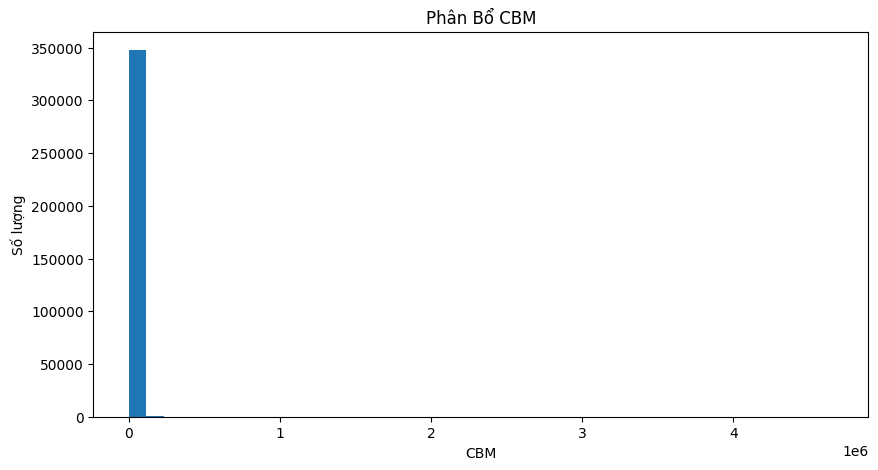

In [ ]:
#Phân bổ cbm sản phẩm
plt.hist(sanpham["cbm_san_pham"], bins=40)

plt.title("Phân Bổ CBM")
plt.xlabel("CBM")
plt.ylabel("Số lượng")

plt.show()

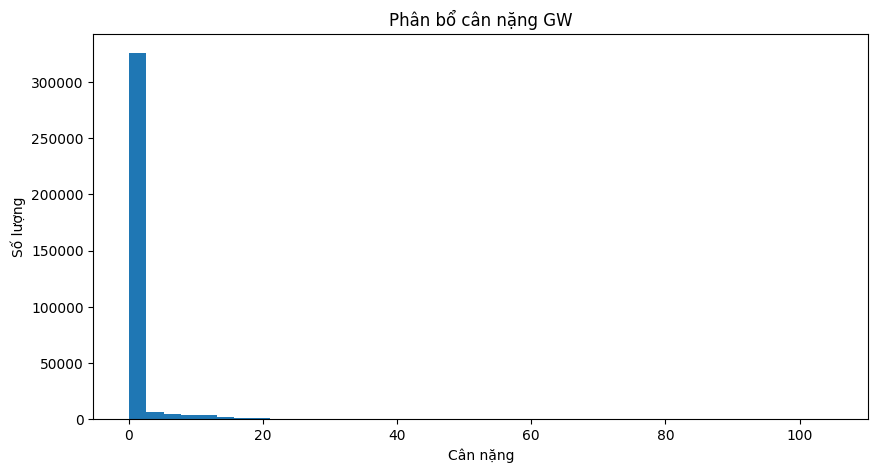

In [ ]:
#Phân bổ cân nặng
plt.hist(sanpham["gw_san_pham"], bins=40)

plt.title("Phân bổ cân nặng GW")
plt.xlabel("Cân nặng")
plt.ylabel("Số lượng")

plt.show()

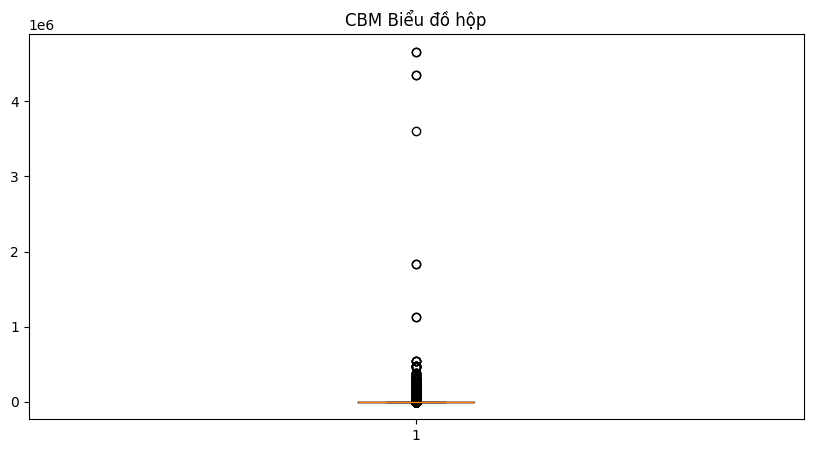

In [ ]:
#biểu đồ hộp
plt.boxplot(sanpham["cbm_san_pham"].dropna())

plt.title("CBM Biểu đồ hộp")

plt.show()
#đánh giá bị áp sát về 0 cho thấy 75% sản phẩm không có cbm hoặc rất nhỏ
#có một số outlier rất lớn vd như 1; 1.9; 3.5; 4.5; 4.6

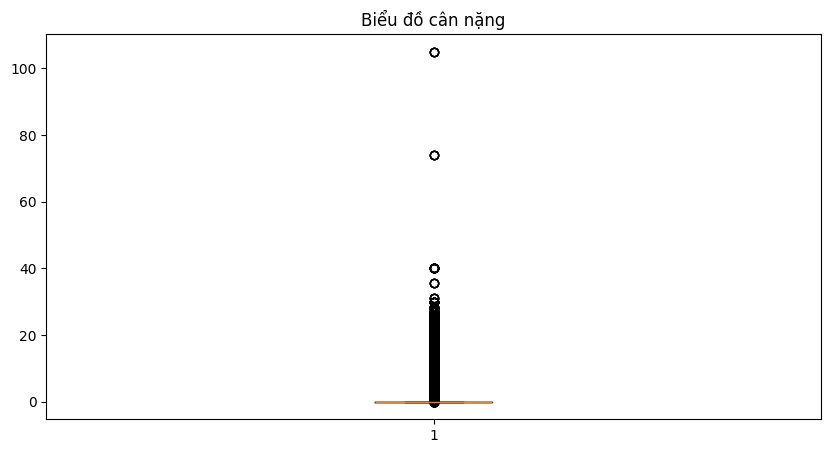

In [ ]:
plt.boxplot(sanpham["gw_san_pham"].dropna())

plt.title("Biểu đồ cân nặng")

plt.show()

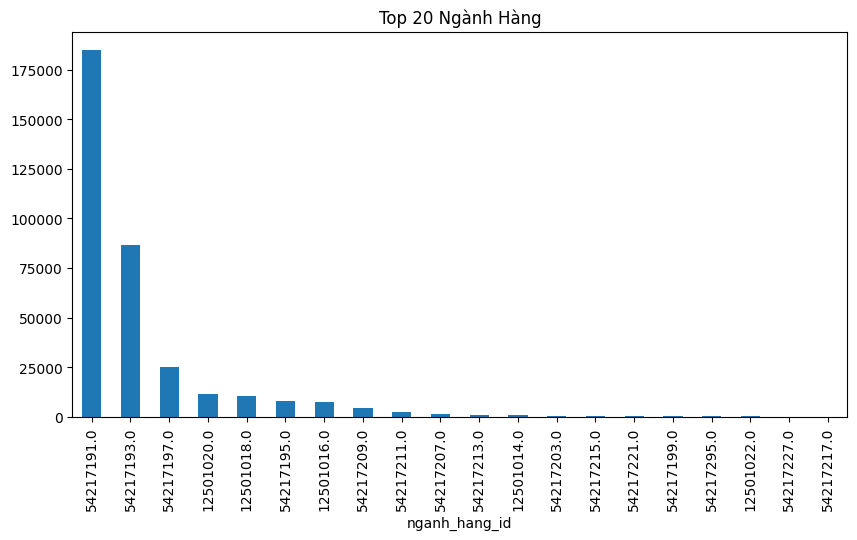

In [ ]:
sanpham["nganh_hang_id"]\
.value_counts()\
.head(20)\
.plot(kind="bar")

plt.title("Top 20 Ngành Hàng")

plt.show()

In [ ]:
#Những sản phẩm có Cbm lớn
sanpham.nlargest(
    20,
    "cbm_san_pham"
)[["ma_san_pham","cbm_san_pham"]]

,ma_san_pham,cbm_san_pham
7717,40007718.0,4660500.0
29319,40029320.0,4660500.0
7735,40007736.0,4356000.0
29336,40029337.0,4356000.0
8583,40008584.0,3608836.0
7548,40007549.0,1830000.0
29158,40029159.0,1830000.0
7576,40007577.0,1128000.0
29185,40029186.0,1128000.0
5120,40005121.0,537370.0


In [ ]:
#những sản phẩm có cân nặng lớn
sanpham.nlargest(
    20,
    "gw_san_pham"
)[["ma_san_pham","gw_san_pham"]]

,ma_san_pham,gw_san_pham
622,40000623.0,105.0
9037,40009038.0,105.0
15712,40015713.0,105.0
23007,40023008.0,105.0
5613,40005614.0,74.0
13787,40013788.0,74.0
20181,40020182.0,74.0
27391,40027392.0,74.0
1003,40001004.0,40.0
1486,40001487.0,40.0


In [ ]:
numeric_columns = [
    "gw_san_pham",
    "nw_san_pham",
    "cbm_san_pham",
    "sl_cai_1_thung",
    "sl_thung_1_pallet"
]

for col in numeric_columns:
    sanpham[col] = pd.to_numeric(sanpham[col], errors="coerce")

In [ ]:
sanpham["cbm_san_pham"].describe()

count    3.482930e+05
mean     2.516387e+03
std      2.112228e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.660500e+06
Name: cbm_san_pham, dtype: float64

In [ ]:
sanpham["cbm_san_pham"].eq(0).mean() 

0.9213530242653223

In [ ]:
sanpham.loc[sanpham["cbm_san_pham"] > 0, "cbm_san_pham"].describe()

count    2.737100e+04
mean     3.202076e+04
std      6.879407e+04
min      2.059000e-02
25%      1.428000e+04
50%      2.353111e+04
75%      3.630000e+04
max      4.660500e+06
Name: cbm_san_pham, dtype: float64

## Vị trí

In [ ]:
print(vitri["ma_so_vi_tri"].nunique())

26700


In [ ]:
vitri["tang"].value_counts().sort_index()

tang
0      968
1     4846
2     3930
3     3765
4     3690
5     2797
6     1666
7     1302
8     1302
9     1302
10    1302
Name: count, dtype: int64

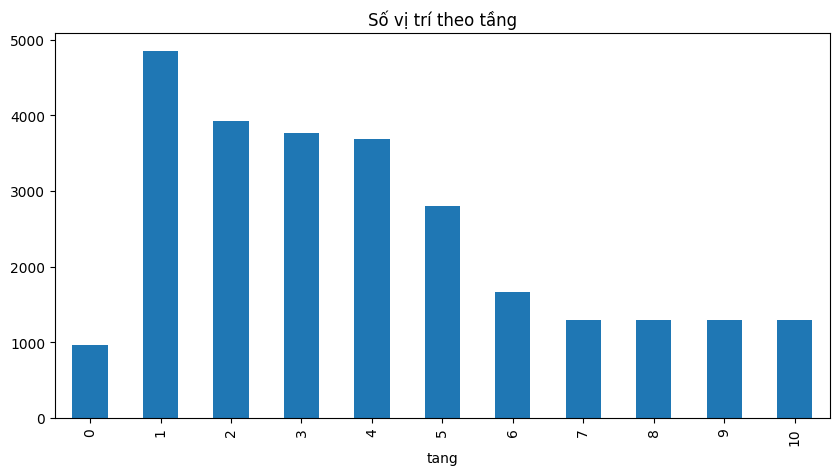

In [ ]:
vitri["tang"]\
.value_counts()\
.sort_index()\
.plot(kind="bar")

plt.title("Số vị trí theo tầng")

plt.show()

In [ ]:
print(vitri["day_ke_id"].nunique())

165


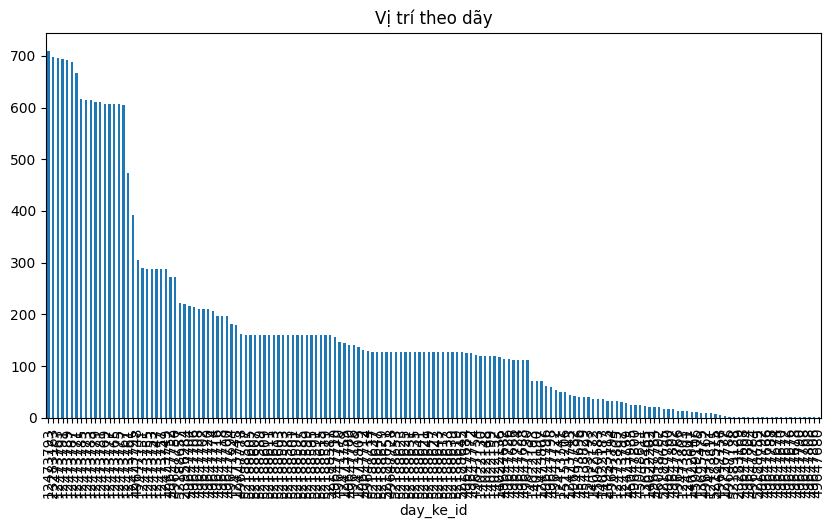

In [ ]:
vitri["day_ke_id"]\
.value_counts()\
.plot(kind="bar")

plt.title("Vị trí theo dãy")

plt.show()

In [ ]:
vitri["cbm_max"].nunique()

41

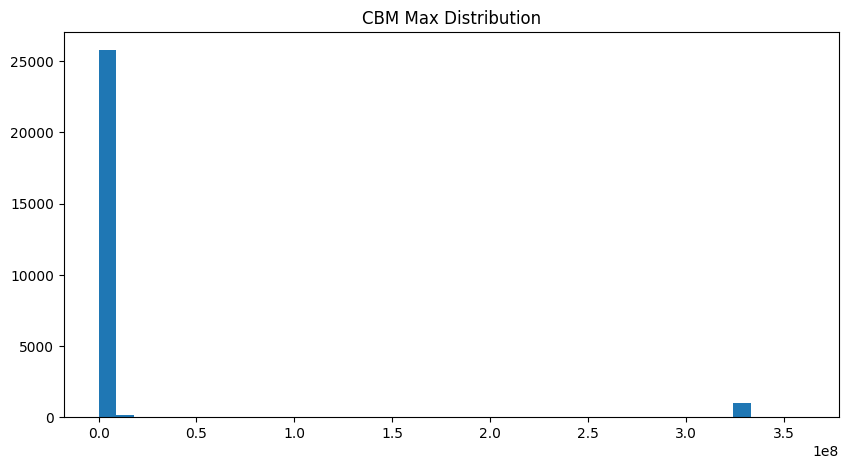

In [ ]:
plt.hist(
    vitri["cbm_max"],
    bins=40
)

plt.title("CBM Max Distribution")

plt.show()

In [ ]:
vitri["cbm_max"]\
.value_counts()\
.head(20)

cbm_max
1.860000e+06    7949
1.620000e+06    3262
1.800000e+06    2450
3.000000e+05    1968
4.700000e+05    1942
3.484800e+05    1424
1.728000e+06    1227
3.274418e+08     957
1.782500e+06     835
1.080000e+06     590
2.819025e+05     568
1.405236e+06     419
8.250000e+05     288
4.565000e+05     276
1.868400e+06     241
9.320733e+05     237
1.497488e+06     230
9.082156e+05     229
1.380000e+06     194
2.000000e+05     180
Name: count, dtype: int64

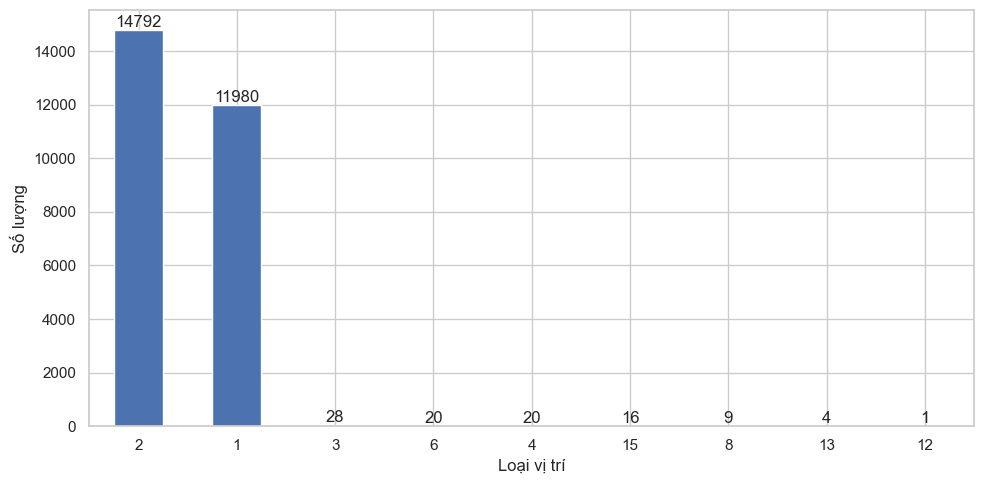

In [15]:
counts = vitri["vi_tri_type_id"].value_counts()

plt.figure(figsize=(10,5))
counts.plot(kind="bar")

plt.ylabel("Số lượng")
plt.xlabel("Loại vị trí")
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [ ]:
vitri["vi_tri_seq_id"]\
.value_counts(normalize=True)

vi_tri_seq_id
0      0.450167
1      0.011574
7      0.011351
5      0.011090
2      0.011016
         ...   
110    0.000037
111    0.000037
107    0.000037
133    0.000037
132    0.000037
Name: proportion, Length: 136, dtype: float64

## Tồn kho

In [ ]:
sku_location = tonkho.groupby(
    "san_pham_id"
)["vi_tri_id"].nunique()

sku_location.describe()

count    8339.000000
mean       21.560499
std        34.145738
min         1.000000
25%         4.000000
50%        11.000000
75%        26.000000
max       741.000000
Name: vi_tri_id, dtype: float64

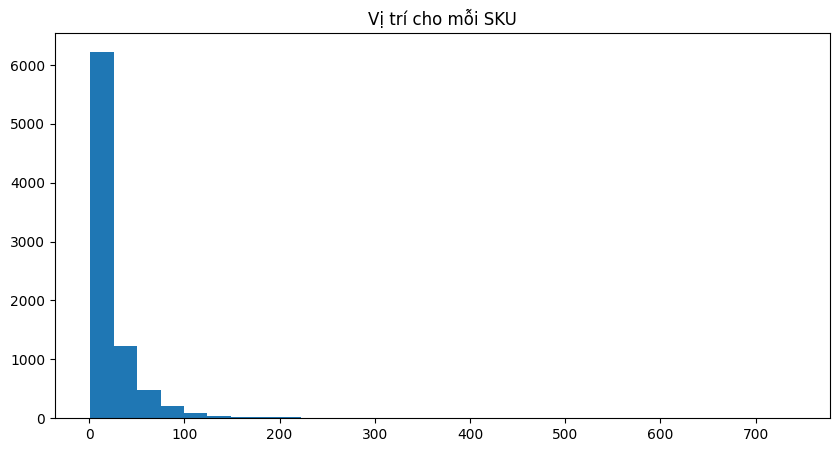

In [ ]:
plt.hist(
    sku_location,
    bins=30
)

plt.title("Vị trí cho mỗi SKU")

plt.show()

In [ ]:
location_sku = tonkho.groupby(
    "vi_tri_id"
)["san_pham_id"].nunique()

location_sku.describe()

count    14436.000000
mean        12.454489
std         99.676837
min          1.000000
25%          3.000000
50%          6.000000
75%         14.000000
max       5767.000000
Name: san_pham_id, dtype: float64

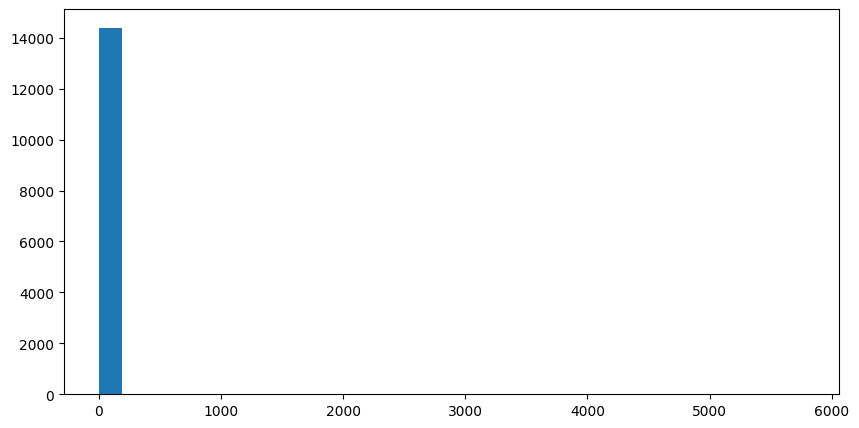

In [ ]:
plt.hist(
    location_sku,
    bins=30
)

plt.show()

In [ ]:
sku_location\
.sort_values(ascending=False)\
.head(20)

san_pham_id
12504907    741
20125251    740
12501409    541
12504285    469
12505449    456
24072104    443
12504875    428
12504277    421
12501295    365
12504893    336
12504905    328
12501055    323
12505435    321
12503145    319
12501111    298
12503705    284
12503153    283
12501103    268
12502943    268
12501069    263
Name: vi_tri_id, dtype: int64

In [ ]:
location_sku\
.sort_values(ascending=False)\
.head(20)

vi_tri_id
20036994    5767
20036974    4932
12473833    4292
20036980    4104
20036982    3117
20036976    3046
20036978    2520
49648529    2317
24488188    1904
12853309    1867
20036984    1714
20883932    1259
12500149    1242
20037014    1208
30072523     977
12934151     773
12473825     717
20036992     641
12473831     618
20036988     580
Name: san_pham_id, dtype: int64

## Xuất Kho

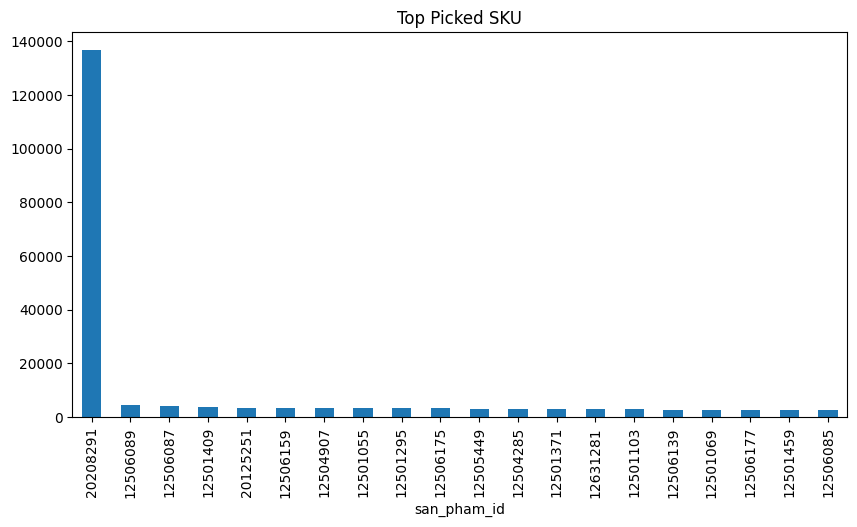

In [ ]:
xuatkho["san_pham_id"]\
.value_counts()\
.head(20)\
.plot(kind="bar")

plt.title("Top Picked SKU")

plt.show()

In [ ]:
xuatkho["vi_tri_id"]\
.value_counts()\
.head(20)

vi_tri_id
20243022    135648
12853309     59089
12934151      9730
30072523      5761
12491260      2778
12491384      2743
12491352      2696
12491380      2527
12491382      2484
12498582      2482
24933128      2468
12491396      2331
12491364      2230
24337747      2212
12491242      2162
12491330      2119
12491346      2100
12491400      2056
24933132      2052
12491392      2021
Name: count, dtype: int64

## Châm Hàng

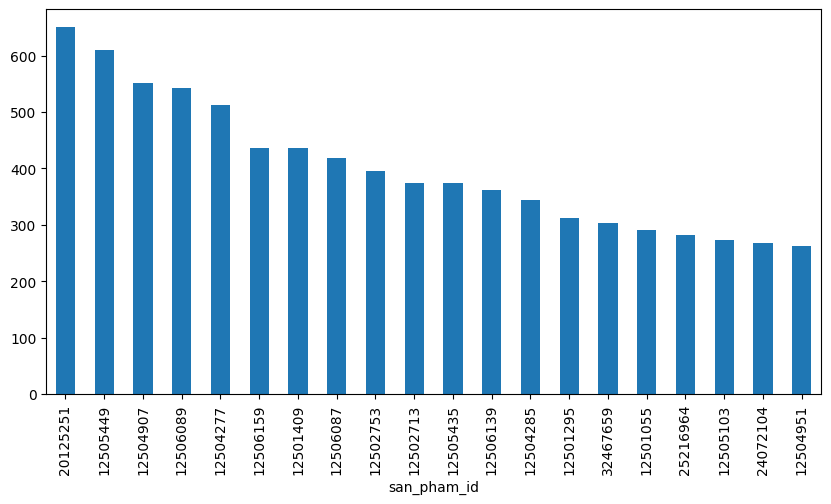

In [ ]:
cham["san_pham_id"]\
.value_counts()\
.head(20)\
.plot(kind="bar")

plt.show()

In [ ]:
top_pick = (
    cham.groupby("ma_so_vi_tri_moi")
        .size()
        .sort_values(ascending=False)
)
print(top_pick.head(50))

ma_so_vi_tri_moi
PB-8151       3336
RA-001         519
A15-013-01     392
RA-003         380
RD-25          333
RD-71          320
A12-070-03     314
A26-057-02     273
A14-054-01     268
A06-005-04     252
RA-002         246
A16-050-01     245
RD-09          243
RD-104         233
RD-51          230
A25-053-01     222
A12-084-01     219
A16-058-02     219
A13-046-01     219
A15-016-04     216
A11-035-01     216
A16-063-01     212
A17-001-01     212
RD-15          210
A12-081-02     209
RD-72          209
A13-085-03     209
A16-037-01     204
A15-042-01     203
RD-03          199
A15-041-03     195
A16-038-02     195
A18-061-01     194
A17-048-02     185
A11-048-03     182
A15-059-01     177
A14-051-02     175
A16-038-01     175
A12-071-02     169
RD-107         167
A24-036-03     166
A20-087-03     165
RD-11          165
A13-084-02     164
A01-044-01     164
A05-019-04     163
A17-037-02     163
A07-041-01     163
RD-17          163
A15-079-03     162
dtype: int64


In [ ]:
top_reserve = (
    cham.groupby("ma_so_vi_tri_cu")
        .size()
        .sort_values(ascending=False)
)
print(top_reserve.head(20))

ma_so_vi_tri_cu
DV000001      2060
DV000007      1181
DV000008      1109
DV000009       322
SLL1           221
DV000003       216
DV000002       177
DV000005       128
R11-054-05     110
SLL            105
DV000010       103
R13-025-05      99
R13-065-05      95
R13-020-05      94
R13-032-05      94
R11-007-05      89
R11-002-05      87
R13-036-05      85
R12-007-05      82
R12-008-05      81
dtype: int64


In [ ]:
sku_move = (
    cham.groupby("san_pham_id")["ma_so_vi_tri_moi"]
        .nunique()
        .sort_values(ascending=False)
)
print(sku_move.head(20))

san_pham_id
12504939    8
12505129    8
12502475    7
12505221    7
20619153    7
12504979    6
12504453    6
12505137    6
13976175    6
12504951    6
12505449    6
12501809    6
12505451    6
12501631    6
12504971    6
12505205    6
12505365    6
12503245    6
12506137    6
12502069    6
Name: ma_so_vi_tri_moi, dtype: int64


In [ ]:
reserve = (
    cham.groupby("san_pham_id")["ma_so_vi_tri_cu"]
        .nunique()
)
print(reserve.head(20))

san_pham_id
12501027     14
12501029     15
12501031     60
12501033     37
12501035     75
12501037     25
12501041     49
12501043     22
12501045      6
12501047      6
12501049     12
12501051     44
12501055    229
12501057     28
12501059     10
12501061     52
12501063    121
12501065     61
12501067    139
12501069    169
Name: ma_so_vi_tri_cu, dtype: int64


## Tỉ lệ lấp đầy kho

In [ ]:
agg = tonkho.groupby("vi_tri_id").agg(
    so_sku=("san_pham_id", "nunique"),
    so_lpn=("so_lpn", "nunique"),
    tong_sl=("sl_nhap_chan", "sum")  # hoặc sl tồn bạn đang dùng
).reset_index()

df = vitri.merge(
    agg,
    left_on="auto_id",
    right_on="vi_tri_id",
    how="left"
)

df["so_sku"] = df["so_sku"].fillna(0)
df["so_lpn"] = df["so_lpn"].fillna(0)

df["trang_thai_vi_tri"] = df["so_sku"].apply(
    lambda x: "TRONG" if x == 0 else "CO_HANG"
)

cohang = (df["trang_thai_vi_tri"] == "CO_HANG").sum()
trong = (df["trang_thai_vi_tri"] == "TRONG").sum()
tong = len(df)

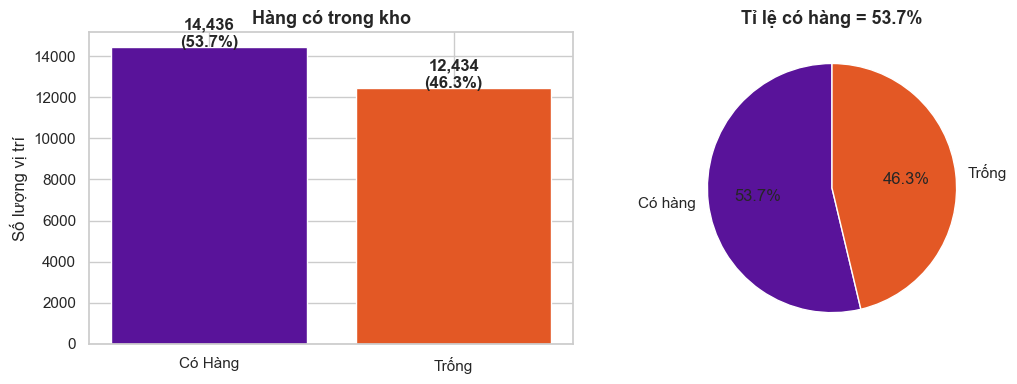

Tỉ lệ có hàng = 53.7%


In [ ]:
fig,ax=plt.subplots(1,2,figsize=(11,4))

# Bar

ax[0].bar(
    ["Có Hàng","Trống"],
    [cohang,trong],
    color=["#59139A","#E35825"]
)

for i,v in enumerate([cohang,trong]):
    ax[0].text(
        i,
        v+20,
        f"{v:,}\n({v/tong:.1%})",
        ha="center",
        fontweight="bold"
    )

ax[0].set_ylabel("Số lượng vị trí")
ax[0].set_title("Hàng có trong kho")

# Pie

ax[1].pie(
    [cohang,trong],
    labels=["Có hàng","Trống"],
    autopct="%1.1f%%",
    colors=["#59139A","#E35825"],
    startangle=90
)

ax[1].set_title(
    f"Tỉ lệ có hàng = {cohang/tong:.1%}"
)

plt.tight_layout()

plt.savefig(IMAGES/"warehouse_occupancy.png",dpi=150)

plt.show()

print(
    f"Tỉ lệ có hàng = {cohang/tong:.1%}"
)

## Cấu trúc sơ đồ kho

In [ ]:
vitri["kho_id"].nunique()

3

In [ ]:
vitri["kho_id"].unique()

array([12473657, 12630830, 12630825], dtype=int64)

In [ ]:
vitri.groupby("kho_id").agg(
    so_vi_tri=("auto_id", "nunique"),
    so_ke=("day_ke_id", "nunique"),
    so_tang=("tang", "nunique")
).sort_values("so_vi_tri", ascending=False)

,so_vi_tri,so_ke,so_tang
kho_id,,,
12473657,15706,63,11
12630825,5722,43,6
12630830,5442,59,7


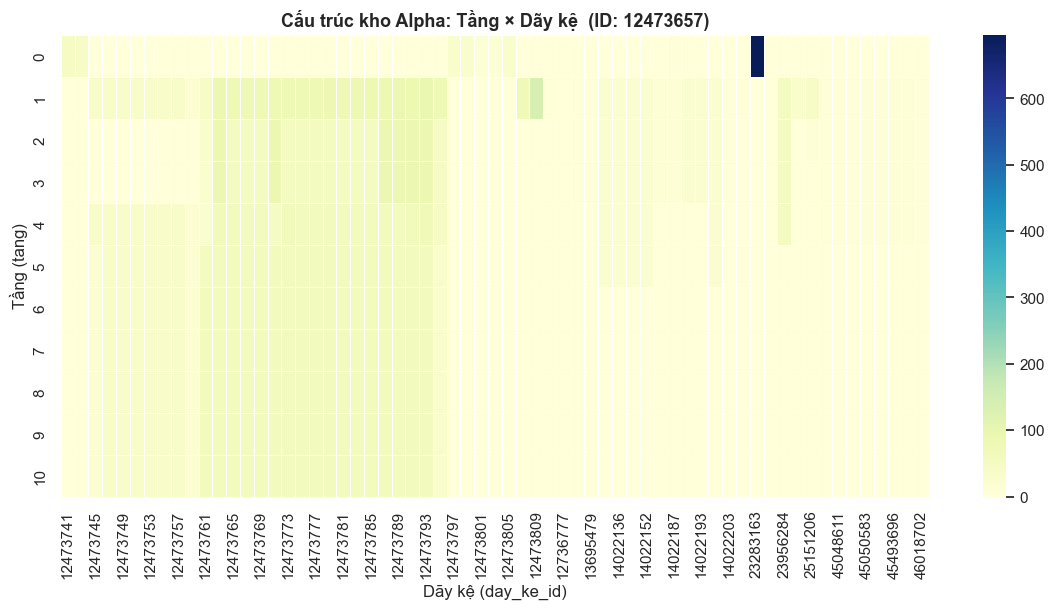

In [ ]:
kho = vitri[vitri["kho_id"] == 12473657]
pivot = kho.groupby(["tang","day_ke_id"])["auto_id"].count().unstack(fill_value=0)
plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Cấu trúc kho Alpha: Tầng × Dãy kệ  (ID: 12473657)")
plt.xlabel("Dãy kệ (day_ke_id)")
plt.ylabel("Tầng (tang)")

plt.show()
#màu càng đậm biểu diễn chỗ đó có nhiều vị trí

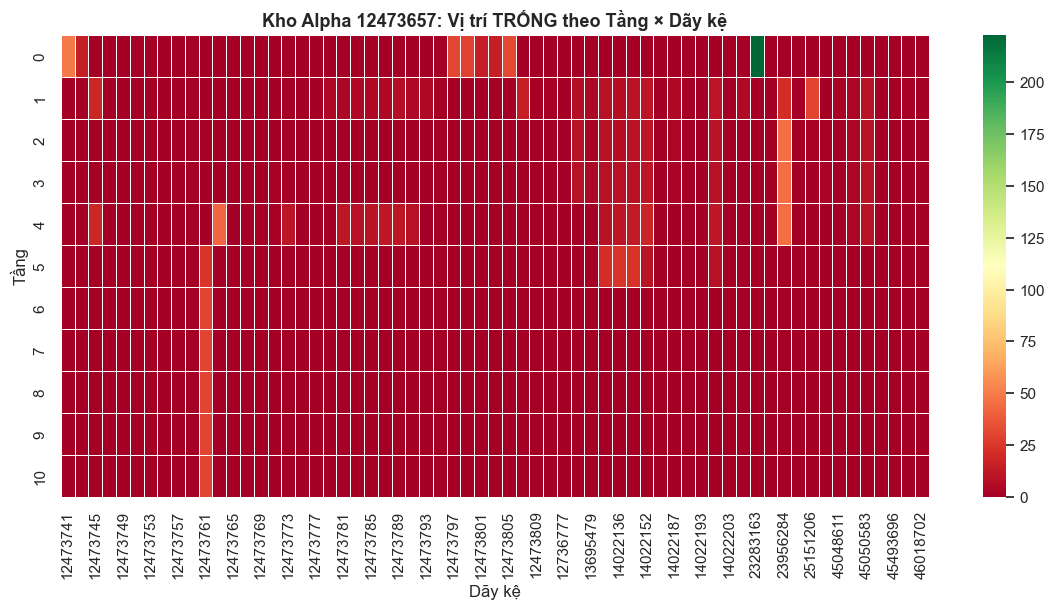

In [137]:
occupied = tonkho.groupby("vi_tri_id")["san_pham_id"].count().reset_index()
occupied.columns = ["auto_id", "has_stock"]

kho = vitri[vitri["kho_id"] == 12473657]

df = kho.merge(
    occupied,
    on="auto_id",
    how="left"
)

df["has_stock"] = df["has_stock"].fillna(0)
df["status"] = df["has_stock"].apply(lambda x: "CÓ HÀNG" if x > 0 else "TRỐNG")

pivot = df.groupby(["tang","day_ke_id"])["status"].apply(
    lambda x: (x == "TRỐNG").sum()
).unstack(fill_value=0)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="RdYlGn",   # đỏ = ít trống, xanh = nhiều trống
    linewidths=0.5,
    linecolor="white"
)

plt.title("Kho Alpha 12473657: Vị trí TRỐNG theo Tầng × Dãy kệ")
plt.xlabel("Dãy kệ")
plt.ylabel("Tầng")

plt.show()

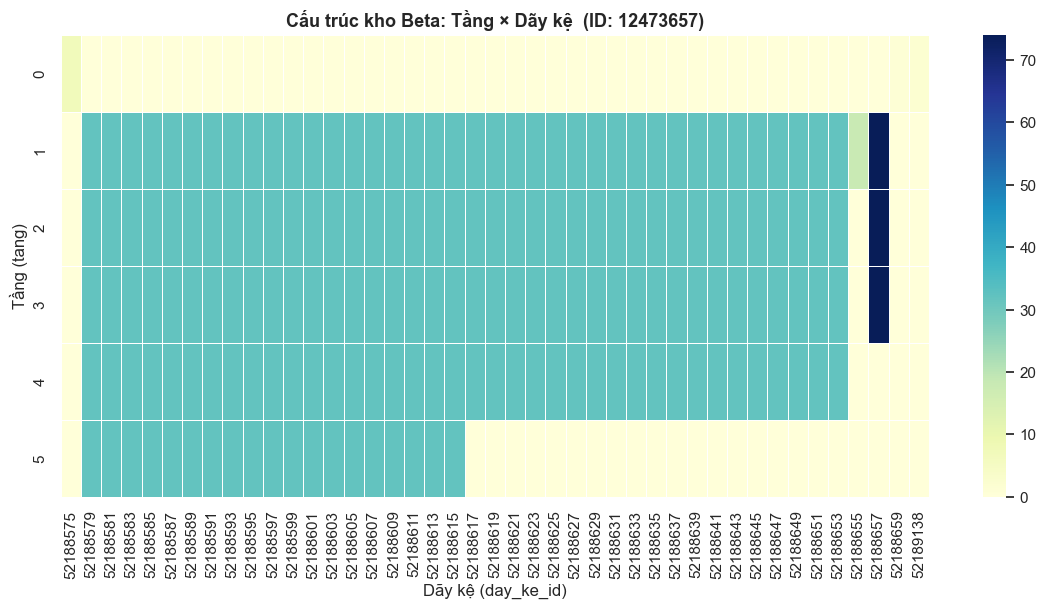

In [ ]:
kho = vitri[vitri["kho_id"] == 12630825]
pivot = kho.groupby(["tang","day_ke_id"])["auto_id"].count().unstack(fill_value=0)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Cấu trúc kho Beta: Tầng × Dãy kệ  (ID: 12630825)")
plt.xlabel("Dãy kệ (day_ke_id)")
plt.ylabel("Tầng (tang)")

plt.show()
#màu càng đậm biểu diễn chỗ đó có nhiều vị trí

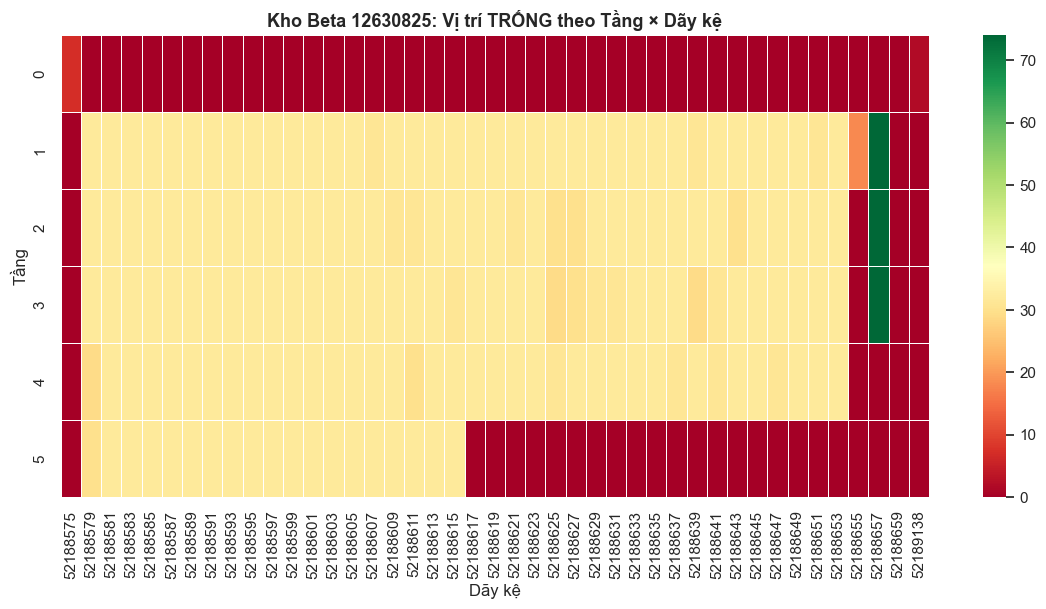

In [138]:
occupied = tonkho.groupby("vi_tri_id")["san_pham_id"].count().reset_index()
occupied.columns = ["auto_id", "has_stock"]

kho = vitri[vitri["kho_id"] == 12630825]

df = kho.merge(
    occupied,
    on="auto_id",
    how="left"
)

df["has_stock"] = df["has_stock"].fillna(0)
df["status"] = df["has_stock"].apply(lambda x: "CÓ HÀNG" if x > 0 else "TRỐNG")

pivot = df.groupby(["tang","day_ke_id"])["status"].apply(
    lambda x: (x == "TRỐNG").sum()
).unstack(fill_value=0)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="RdYlGn",   # đỏ = ít trống, xanh = nhiều trống
    linewidths=0.5,
    linecolor="white"
)

plt.title("Kho Beta 12630825: Vị trí TRỐNG theo Tầng × Dãy kệ")
plt.xlabel("Dãy kệ")
plt.ylabel("Tầng")

plt.show()

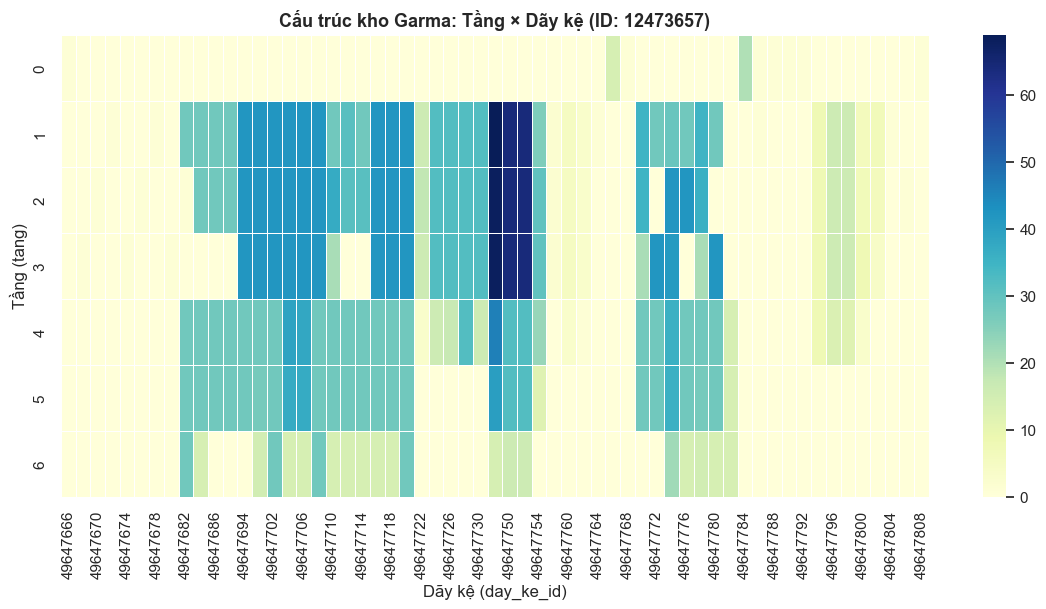

In [ ]:
kho = vitri[vitri["kho_id"] == 12630830]
pivot = kho.groupby(["tang","day_ke_id"])["auto_id"].count().unstack(fill_value=0)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Cấu trúc kho Garma: Tầng × Dãy kệ (ID: 12630830)")
plt.xlabel("Dãy kệ (day_ke_id)")
plt.ylabel("Tầng (tang)")

plt.show()
#màu càng đậm biểu diễn chỗ đó có nhiều vị trí

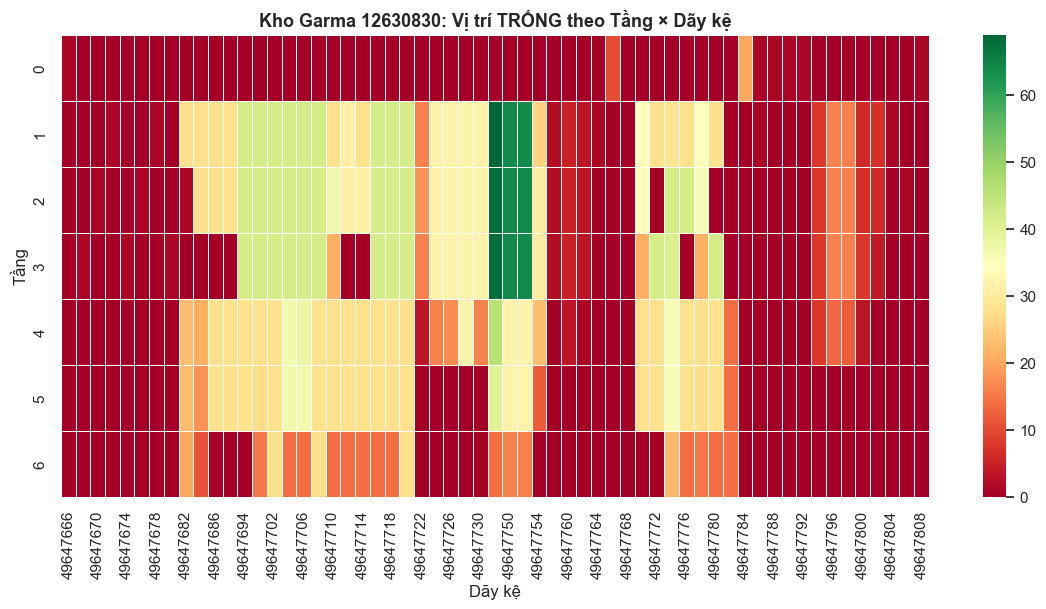

In [139]:
occupied = tonkho.groupby("vi_tri_id")["san_pham_id"].count().reset_index()
occupied.columns = ["auto_id", "has_stock"]

kho = vitri[vitri["kho_id"] == 12630830]

df = kho.merge(
    occupied,
    on="auto_id",
    how="left"
)

df["has_stock"] = df["has_stock"].fillna(0)
df["status"] = df["has_stock"].apply(lambda x: "CÓ HÀNG" if x > 0 else "TRỐNG")

pivot = df.groupby(["tang","day_ke_id"])["status"].apply(
    lambda x: (x == "TRỐNG").sum()
).unstack(fill_value=0)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="RdYlGn",   # đỏ = ít trống, xanh = nhiều trống
    linewidths=0.5,
    linecolor="white"
)

plt.title("Kho Garma 12630830: Vị trí TRỐNG theo Tầng × Dãy kệ")
plt.xlabel("Dãy kệ")
plt.ylabel("Tầng")

plt.show()

In [140]:
pick_flow = xuatkho.groupby("san_pham_id").agg(
    pick_count=("auto_id", "count"),
    total_qty=("sl_allocated_chan", "sum")
).reset_index()

pick_flow.sort_values("pick_count", ascending=False).head(10)

,san_pham_id,pick_count,total_qty
4506,20208291,136622,899931.123
2332,12506089,4596,106748.000
2331,12506087,4196,1821000.000
185,12501409,3693,1689930.000
4455,20125251,3498,229425.000
2366,12506159,3429,62568.000
1798,12504907,3368,119390.000
13,12501055,3219,63495.000
128,12501295,3184,376752.000
2374,12506175,3154,145116.000


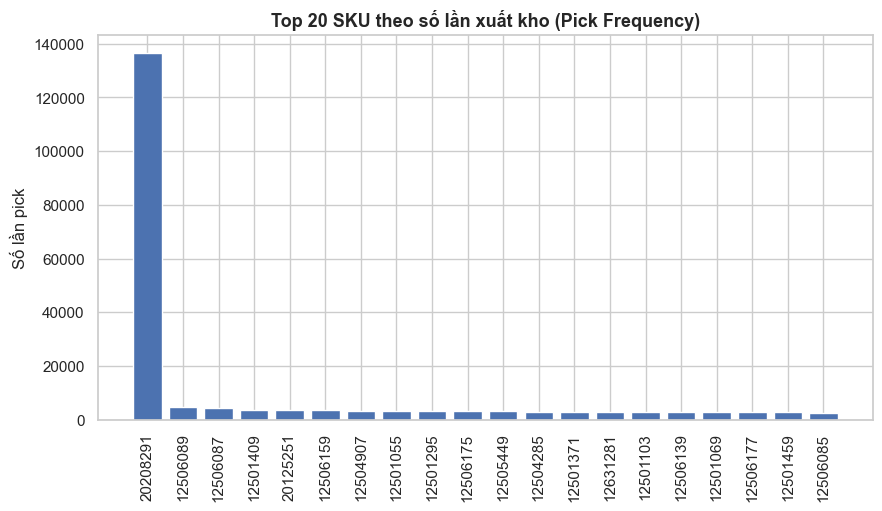

In [141]:
top_pick = pick_flow.sort_values("pick_count", ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.bar(top_pick["san_pham_id"].astype(str), top_pick["pick_count"])
plt.xticks(rotation=90)
plt.title("Top 20 SKU theo số lần xuất kho (Pick Frequency)")
plt.ylabel("Số lần pick")
plt.show()

In [142]:
rep_flow = cham.groupby("san_pham_id").agg(
    rep_count=("auto_id", "count")
).reset_index()

rep_flow.sort_values("rep_count", ascending=False).head(10)

,san_pham_id,rep_count
3426,20125251,650
1887,12505449,610
1666,12504907,551
2022,12506089,542
1400,12504277,513
2055,12506159,436
183,12501409,436
2021,12506087,418
799,12502753,395
782,12502713,374


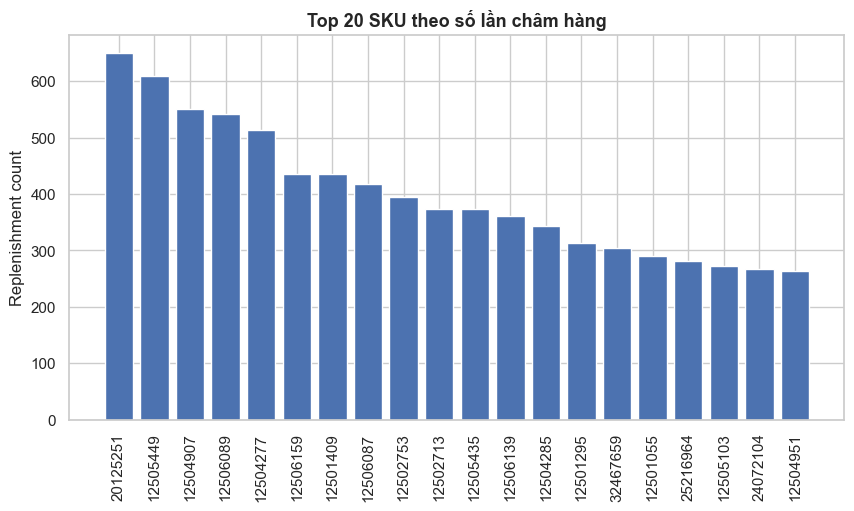

In [143]:
top_rep = rep_flow.sort_values("rep_count", ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.bar(top_rep["san_pham_id"].astype(str), top_rep["rep_count"])
plt.xticks(rotation=90)
plt.title("Top 20 SKU theo số lần châm hàng")
plt.ylabel("Replenishment count")
plt.show()

In [144]:
flow = pick_flow.merge(rep_flow, on="san_pham_id", how="outer").fillna(0)
flow["imbalance"] = flow["rep_count"] / (flow["pick_count"] + 1)

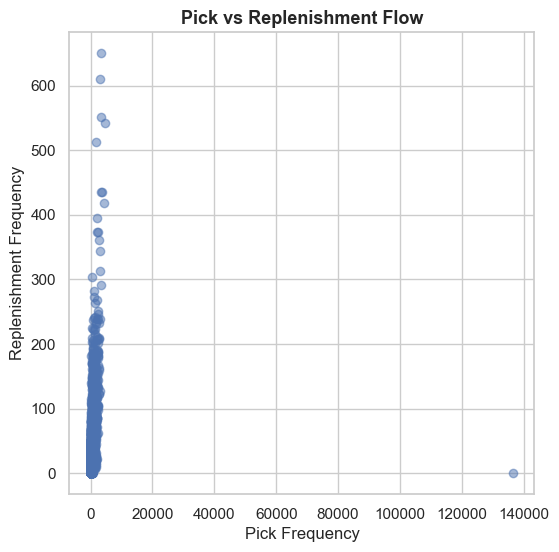

In [145]:
plt.figure(figsize=(6,6))

plt.scatter(
    flow["pick_count"],
    flow["rep_count"],
    alpha=0.5
)

plt.xlabel("Pick Frequency")
plt.ylabel("Replenishment Frequency")
plt.title("Pick vs Replenishment Flow")

plt.show()